Imports and Dependencies

In [1]:
import sys

!{sys.executable} -m pip install transformers torch datasets

In [2]:
import numpy as np
import pandas as pd
import json

JSON data loading & inspection

In [3]:
file = open("/Users/yash/Documents/Uni Assignments/CODE files/AI Applications/AI_GROUP_PROJECT/data/CUADv1.json", "r")

data = json.load(file)

file.close()

In [4]:
#Check Top-Level Keys

data.keys()

dict_keys(['version', 'data'])

In [5]:
#Check Number of Documents

len(data["data"])

510

In [6]:
#Inspect First Document Structure

data["data"][0].keys()

dict_keys(['title', 'paragraphs'])

In [7]:
# CELL 6 — Inspect First Paragraph

data["data"][0]["paragraphs"][0].keys()

dict_keys(['qas', 'context'])

In [8]:
# CELL 7 — Inspect First QA Example

data["data"][0]["paragraphs"][0]["qas"][0]

{'answers': [{'text': 'DISTRIBUTOR AGREEMENT', 'answer_start': 44}],
 'id': 'LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGREEMENT__Document Name',
 'question': 'Highlight the parts (if any) of this contract related to "Document Name" that should be reviewed by a lawyer. Details: The name of the contract',
 'is_impossible': False}

In [9]:
# CELL 8 — Extract Important Fields

rows = []

for document in data["data"]:
    
    title = document.get("title", "")
    
    for paragraph in document["paragraphs"]:
        
        context = paragraph.get("context", "")
        
        for qa in paragraph["qas"]:
            
            question = qa.get("question", "").strip()
            
            answers = qa.get("answers", [])
            
            if len(answers) == 0:
                continue
            
            for ans in answers:
                
                clause_text = ans.get("text", "").strip()
                
                if clause_text == "":
                    continue
                
                rows.append({
                    "title": title,
                    "question": question,
                    "clause_text": clause_text,
                    "context": context
                })

In [10]:
# CELL 9 — Create DataFrame

df = pd.DataFrame(rows)

df.head()

,title,question,clause_text,context
0,LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,Highlight the parts (if any) of this contract ...,DISTRIBUTOR AGREEMENT,EXHIBIT 10.6\n\n ...
1,LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,Highlight the parts (if any) of this contract ...,Distributor,EXHIBIT 10.6\n\n ...
2,LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,Highlight the parts (if any) of this contract ...,Electric City Corp.,EXHIBIT 10.6\n\n ...
3,LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,Highlight the parts (if any) of this contract ...,Electric City of Illinois L.L.C.,EXHIBIT 10.6\n\n ...
4,LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,Highlight the parts (if any) of this contract ...,Company,EXHIBIT 10.6\n\n ...


In [13]:
# CELL 10 — Dataset Shape

df.shape

(13823, 4)

In [14]:
# CELL 11 — View Random Samples

df.sample(5)

,title,question,clause_text,context
2098,TELEGLOBEINTERNATIONALHOLDINGSLTD_03_29_2004-E...,Highlight the parts (if any) of this contract ...,GTE Intelligent Network Service Incorporated,Exhibit 10.10 ASIA PACIFIC CABLE NETWORK 2 ...
11460,SEASPINEHOLDINGSCORP_10_10_2018-EX-10.1-SUPPLY...,Highlight the parts (if any) of this contract ...,Subject to the terms and conditions of this Ag...,Exhibit 10.1\n\nCERTAIN CONFIDENTIAL INFORMATI...
11399,BIOAMBERINC_04_10_2013-EX-10.34-DEVELOPMENT AG...,Highlight the parts (if any) of this contract ...,"Cargill hereby grants Bioamber, and Bioamber h...",Exhibit 10.34\n\n*** Text Omitted and Filed Se...
10834,RemarkHoldingsInc_20081114_10-Q_EX-10.24_28956...,Highlight the parts (if any) of this contract ...,"In addition, such license for Translated Conte...",Exhibit 10.24 *Portions of this exhibit mar...
5783,AULAMERICANUNITTRUST_04_24_2020-EX-99.8.77-SER...,Highlight the parts (if any) of this contract ...,American United Life Insurance Company,Exhibit 8.77 SERVICING AGREEMENT NATIONWIDE MU...


In [15]:
# CELL 12 — Save Clean Dataset

df.to_csv("cuad_clause_dataset.csv", index=False)

print("Dataset saved successfully.")

Dataset saved successfully.


Question-to-Clause-Type Label Mapping

CUAD uses 41 detailed legal questions as QA labels.

We map these to simplified clause type labels for classification.

We then filter to the 10 most legally significant and data-rich categories.

In [ ]:
QUESTION_TO_CLAUSE_TYPE = {
    # Parties and Duration
    "Parties": "parties",
    "Agreement Date": "agreement_date",
    "Effective Date": "effective_date",
    "Expiration Date": "expiration_date",
    "Renewal Term": "renewal",
    "Notice Period To Terminate Renewal": "termination_notice",

    # Termination
    "Termination For Convenience": "termination",
    "Rofr/Rofo/Rofn": "termination",

    # Governing Law and Jurisdiction
    "Governing Law": "governing_law",
    "Jurisdiction": "governing_law",
    "Dispute Resolution": "dispute_resolution",

    # Liability
    "Limitation Of Liability": "limitation_of_liability",
    "Cap On Liability": "limitation_of_liability",
    "Liquidated Damages": "limitation_of_liability",

    # Intellectual Property
    "Ip Ownership Assignment": "intellectual_property",
    "License Grant": "intellectual_property",
    "Non-Transferable License": "intellectual_property",

    # Confidentiality
    "Non-Compete": "confidentiality_non_compete",
    "Non-Disparagement": "confidentiality_non_compete",
    "No-Solicit Of Customers": "confidentiality_non_compete",
    "No-Solicit Of Employees": "confidentiality_non_compete",
    "Non-Disparagement": "confidentiality_non_compete",

    # Payment
    "Revenue/Profit Sharing": "payment",
    "Price Restrictions": "payment",
    "Minimum Commitment": "payment",
    "Volume Restriction": "payment",

    # Indemnification
    "Indemnification": "indemnification",

    # Warranties
    "Warranty Duration": "warranties",
    "Product Warranty": "warranties",
    "Insurance": "warranties",

    # Change of Control
    "Change Of Control": "change_of_control",
    "Anti-Assignment": "change_of_control",

    # Audit Rights
    "Audit Rights": "audit_rights",
    "Most Favored Nation": "audit_rights",
    "Uncapped Liability": "audit_rights",

    # Exclusivity
    "Exclusivity": "exclusivity",
    "Covenant Not To Sue": "exclusivity",
}

# Target clause types (10 categories — balanced scope for academic work)
TARGET_CLAUSE_TYPES = [
    "termination",
    "governing_law",
    "limitation_of_liability",
    "intellectual_property",
    "confidentiality_non_compete",
    "payment",
    "indemnification",
    "warranties",
    "change_of_control",
    "dispute_resolution",
]

print(f"Total question mappings defined: {len(QUESTION_TO_CLAUSE_TYPE)}")
print(f"Target clause categories: {len(TARGET_CLAUSE_TYPES)}")


Total question mappings defined: 36
Target clause categories: 10


Apply Label Mapping and Filter Dataset

In [17]:
def map_question_to_clause_type(question: str) -> str | None:
    """
    Maps a raw CUAD question string to a simplified clause type label.
    Returns None if no mapping exists or clause type is not in target set.
    """
    for key, clause_type in QUESTION_TO_CLAUSE_TYPE.items():
        if key.lower() in question.lower():
            if clause_type in TARGET_CLAUSE_TYPES:
                return clause_type
    return None


df["clause_type"] = df["question"].apply(map_question_to_clause_type)

# Drop rows with no mapping
df_classified = df.dropna(subset=["clause_type"]).copy()
df_classified = df_classified[["clause_text", "clause_type"]].reset_index(drop=True)

print(f"Rows before label mapping:  {len(df)}")
print(f"Rows after label mapping:   {len(df_classified)}")
print(f"\nClause type distribution:")
print(df_classified["clause_type"].value_counts())

Rows before label mapping:  13823
Rows after label mapping:   6893

Clause type distribution:
clause_type
intellectual_property          1742
payment                        1040
change_of_control               907
limitation_of_liability         793
warranties                      736
termination                     613
confidentiality_non_compete     598
governing_law                   464
Name: count, dtype: int64


In [18]:
# %% [markdown]
# ## Cell 15 — Data Cleaning
#
# - Remove duplicate clause texts (same text mapped multiple times)
# - Remove very short clause texts (< 20 characters — likely noise or extraction artifacts)
# - Enforce a minimum of 50 samples per class for reliable fine-tuning

# %%
MIN_CLAUSE_LENGTH = 20
MIN_SAMPLES_PER_CLASS = 50

# Drop duplicates
df_clean = df_classified.drop_duplicates(subset=["clause_text"]).copy()

# Drop very short texts
df_clean = df_clean[df_clean["clause_text"].str.len() >= MIN_CLAUSE_LENGTH].copy()

# Drop clause types with insufficient samples
class_counts = df_clean["clause_type"].value_counts()
valid_classes = class_counts[class_counts >= MIN_SAMPLES_PER_CLASS].index.tolist()
df_clean = df_clean[df_clean["clause_type"].isin(valid_classes)].reset_index(drop=True)

print(f"Rows after cleaning: {len(df_clean)}")
print(f"\nFinal clause type distribution:")
print(df_clean["clause_type"].value_counts())

Rows after cleaning: 6226

Final clause type distribution:
clause_type
intellectual_property          1248
payment                        1010
change_of_control               854
limitation_of_liability         773
warranties                      722
termination                     606
confidentiality_non_compete     561
governing_law                   452
Name: count, dtype: int64


In [19]:
# %% [markdown]
# ## Cell 16 — Label Encoding

# %%
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
df_clean["label"] = label_encoder.fit_transform(df_clean["clause_type"])

NUM_CLASSES = len(label_encoder.classes_)
LABEL_NAMES = list(label_encoder.classes_)

print(f"Number of classes: {NUM_CLASSES}")
print(f"\nLabel encoding:")
for i, name in enumerate(LABEL_NAMES):
    print(f"  {i:2d}  {name}")

Number of classes: 8

Label encoding:
   0  change_of_control
   1  confidentiality_non_compete
   2  governing_law
   3  intellectual_property
   4  limitation_of_liability
   5  payment
   6  termination
   7  warranties


In [20]:
# %% [markdown]
# ## Cell 17 — Train / Validation / Test Split (Stratified)

# %%
from sklearn.model_selection import train_test_split

X = df_clean["clause_text"].tolist()
y = df_clean["label"].tolist()

# 70% train, 15% val, 15% test — stratified to preserve class ratios
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42
)

print(f"Train size:      {len(X_train)}")
print(f"Validation size: {len(X_val)}")
print(f"Test size:       {len(X_test)}")

Train size:      4358
Validation size: 934
Test size:       934


In [24]:
# %% [markdown]
# ## Cell 18 — Tokenizer Setup (Legal-BERT)
#
# Primary model: nlpaueb/legal-bert-base-uncased
# This model is pre-trained on EU legislation, ECJ cases, and US contracts,
# giving it much stronger legal vocabulary coverage than general BERT.

# %%
from transformers import AutoTokenizer

MODEL_NAME = "nlpaueb/legal-bert-base-uncased"
MAX_LENGTH = 256  # Legal clauses can be long; 256 is a practical ceiling

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

print(f"Tokenizer loaded: {MODEL_NAME}")
print(f"Vocabulary size:  {tokenizer.vocab_size}")
print(f"Max token length used: {MAX_LENGTH}")

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Tokenizer loaded: nlpaueb/legal-bert-base-uncased
Vocabulary size:  30522
Max token length used: 256


In [25]:
# %% [markdown]
# ## Cell 19 — PyTorch Dataset Class

# %%
import torch
from torch.utils.data import Dataset, DataLoader


class LegalClauseDataset(Dataset):
    """
    PyTorch Dataset for tokenized legal clause classification.
    Each sample returns input_ids, attention_mask, and label tensor.
    """

    def __init__(self, texts: list[str], labels: list[int], tokenizer, max_length: int):
        self.encodings = tokenizer(
            texts,
            truncation=True,
            padding="max_length",
            max_length=max_length,
            return_tensors="pt",
        )
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            "input_ids":      self.encodings["input_ids"][idx],
            "attention_mask": self.encodings["attention_mask"][idx],
            "labels":         self.labels[idx],
        }


In [26]:
# Build datasets
train_dataset = LegalClauseDataset(X_train, y_train, tokenizer, MAX_LENGTH)
val_dataset   = LegalClauseDataset(X_val,   y_val,   tokenizer, MAX_LENGTH)
test_dataset  = LegalClauseDataset(X_test,  y_test,  tokenizer, MAX_LENGTH)

# DataLoaders
BATCH_SIZE = 16

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

print(f"Train batches:      {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")
print(f"Test batches:       {len(test_loader)}")

Train batches:      273
Validation batches: 59
Test batches:       59


In [27]:
# %% [markdown]
# ## Cell 20 — Class Weights for Imbalanced Data
#
# CUAD has natural class imbalance. We compute inverse-frequency weights
# so the loss function penalises misclassifying rare clause types more heavily.

# %%
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(NUM_CLASSES),
    y=y_train,
)

class_weights_tensor = torch.tensor(class_weights, dtype=torch.float)

print("Class weights (higher = rarer class, penalised more during training):")
for i, (name, weight) in enumerate(zip(LABEL_NAMES, class_weights)):
    print(f"  {name:<35s}  {weight:.4f}")


Class weights (higher = rarer class, penalised more during training):
  change_of_control                    0.9110
  confidentiality_non_compete          1.3861
  governing_law                        1.7239
  intellectual_property                0.6233
  limitation_of_liability              1.0069
  payment                              0.7705
  termination                          1.2848
  warranties                           1.0787


In [28]:
# ## Cell 21 — Model Setup (Legal-BERT Fine-tuning)

# %%
from transformers import AutoModelForSequenceClassification

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training device: {device}")

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_CLASSES,
)
model = model.to(device)
class_weights_tensor = class_weights_tensor.to(device)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Training device: cpu


[transformers] You passed `num_labels=8` which is incompatible to the `id2label` map of length `2`.


pytorch_model.bin:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: nlpaueb/legal-bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those 

Total parameters:     109,488,392
Trainable parameters: 109,488,392


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

In [29]:
# %% [markdown]
# ## Cell 22 — Optimizer and Scheduler
#
# We use AdamW (standard for transformer fine-tuning) with a linear warmup
# schedule. Warmup prevents large gradient updates in early steps that can
# destabilise pre-trained weights.

# %%
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup

EPOCHS       = 4
LEARNING_RATE = 2e-5
WARMUP_RATIO  = 0.1  # 10% of total steps used for warmup

total_steps  = len(train_loader) * EPOCHS
warmup_steps = int(total_steps * WARMUP_RATIO)

optimizer = AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=0.01)

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps,
)

print(f"Epochs:        {EPOCHS}")
print(f"Total steps:   {total_steps}")
print(f"Warmup steps:  {warmup_steps}")
print(f"Learning rate: {LEARNING_RATE}")


Epochs:        4
Total steps:   1092
Warmup steps:  109
Learning rate: 2e-05


In [31]:
# %% [markdown]
# ## Cell 23 — Training Loop with Validation

# %%
import torch.nn as nn
from tqdm.auto import tqdm

loss_fn = nn.CrossEntropyLoss(weight=class_weights_tensor)

history = {
    "train_loss": [],
    "val_loss":   [],
    "val_accuracy": [],
}


def run_epoch_train(model, loader, optimizer, scheduler, loss_fn, device):
    model.train()
    total_loss = 0

    for batch in tqdm(loader, desc="  Training", leave=False):
        input_ids      = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels         = batch["labels"].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        loss    = loss_fn(outputs.logits, labels)
        loss.backward()

        # Gradient clipping prevents exploding gradients
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()
        scheduler.step()

        total_loss += loss.item()

    return total_loss / len(loader)


def run_epoch_eval(model, loader, loss_fn, device):
    model.eval()
    total_loss  = 0
    correct     = 0
    total       = 0

    with torch.no_grad():
        for batch in tqdm(loader, desc="  Validation", leave=False):
            input_ids      = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels         = batch["labels"].to(device)

            outputs    = model(input_ids=input_ids, attention_mask=attention_mask)
            loss       = loss_fn(outputs.logits, labels)
            preds      = torch.argmax(outputs.logits, dim=1)

            total_loss += loss.item()
            correct    += (preds == labels).sum().item()
            total      += labels.size(0)

    avg_loss = total_loss / len(loader)
    accuracy = correct / total
    return avg_loss, accuracy


# Training loop
print(f"Starting Legal-BERT fine-tuning on {device}\n{'='*50}")

for epoch in range(1, EPOCHS + 1):
    print(f"\nEpoch {epoch}/{EPOCHS}")

    train_loss            = run_epoch_train(model, train_loader, optimizer, scheduler, loss_fn, device)
    val_loss, val_accuracy = run_epoch_eval(model, val_loader, loss_fn, device)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_accuracy"].append(val_accuracy)

    print(f"  Train Loss: {train_loss:.4f}  |  Val Loss: {val_loss:.4f}  |  Val Accuracy: {val_accuracy:.4f}")

print("\nTraining complete.")

Starting Legal-BERT fine-tuning on cpu

Epoch 1/4


  Training:   0%|          | 0/273 [00:00<?, ?it/s]

  Validation:   0%|          | 0/59 [00:00<?, ?it/s]

  Train Loss: 0.2220  |  Val Loss: 0.2742  |  Val Accuracy: 0.9272

Epoch 2/4


  Training:   0%|          | 0/273 [00:00<?, ?it/s]

...

  Validation:   0%|          | 0/59 [00:00<?, ?it/s]

  Train Loss: 0.0784  |  Val Loss: 0.2794  |  Val Accuracy: 0.9304

Epoch 4/4


  Training:   0%|          | 0/273 [00:00<?, ?it/s]

  Validation:   0%|          | 0/59 [00:00<?, ?it/s]

  Train Loss: 0.0654  |  Val Loss: 0.2794  |  Val Accuracy: 0.9304

Training complete.


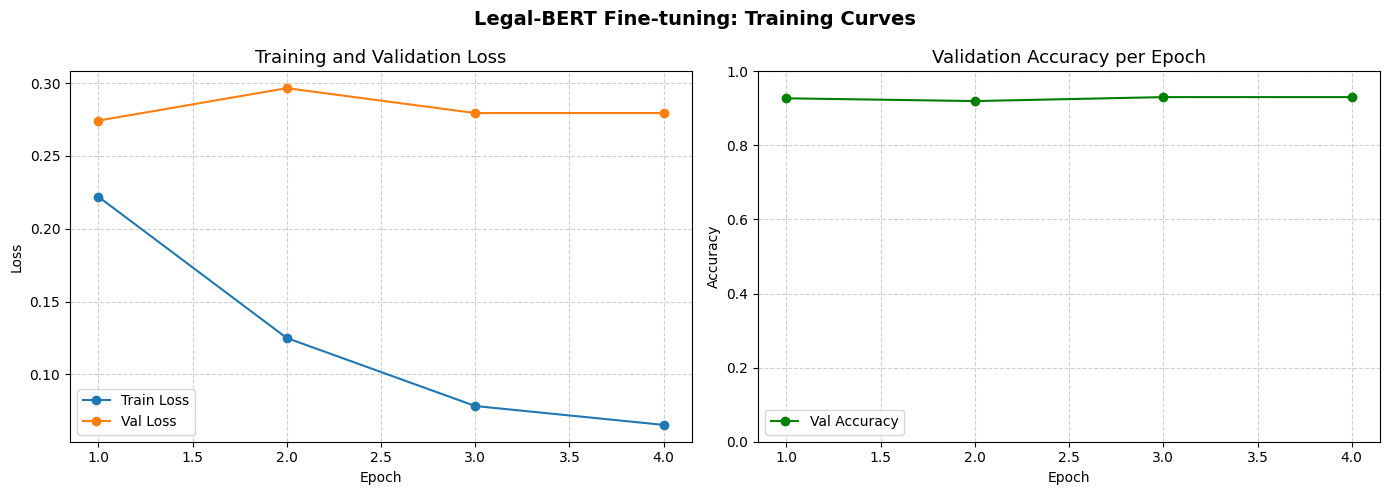

Training curves saved.


In [32]:
# %% [markdown]
# ## Cell 24 — Training Curves

# %%
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs_range = range(1, EPOCHS + 1)

axes[0].plot(epochs_range, history["train_loss"], marker="o", label="Train Loss")
axes[0].plot(epochs_range, history["val_loss"],   marker="o", label="Val Loss")
axes[0].set_title("Training and Validation Loss", fontsize=13)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True, linestyle="--", alpha=0.6)

axes[1].plot(epochs_range, history["val_accuracy"], marker="o", color="green", label="Val Accuracy")
axes[1].set_title("Validation Accuracy per Epoch", fontsize=13)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_ylim(0, 1)
axes[1].legend()
axes[1].grid(True, linestyle="--", alpha=0.6)

plt.suptitle("Legal-BERT Fine-tuning: Training Curves", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("training_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("Training curves saved.")

In [33]:
# %% [markdown]
# ## Cell 25 — Test Set Evaluation

# %%
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
)

model.eval()
all_preds  = []
all_labels = []

with torch.no_grad():
    for batch in tqdm(test_loader, desc="Evaluating on test set"):
        input_ids      = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels         = batch["labels"].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        preds   = torch.argmax(outputs.logits, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_accuracy    = accuracy_score(all_labels, all_preds)
test_f1_macro    = f1_score(all_labels, all_preds, average="macro")
test_f1_weighted = f1_score(all_labels, all_preds, average="weighted")

print(f"\nTest Set Results")
print(f"{'='*40}")
print(f"Accuracy:        {test_accuracy:.4f}")
print(f"F1 (macro):      {test_f1_macro:.4f}")
print(f"F1 (weighted):   {test_f1_weighted:.4f}")

print(f"\nPer-Class Classification Report:")
print(classification_report(all_labels, all_preds, target_names=LABEL_NAMES, digits=4))

Evaluating on test set:   0%|          | 0/59 [00:00<?, ?it/s]


Test Set Results
Accuracy:        0.9486
F1 (macro):      0.9492
F1 (weighted):   0.9488

Per-Class Classification Report:
                             precision    recall  f1-score   support

          change_of_control     0.9302    0.9375    0.9339       128
confidentiality_non_compete     0.8977    0.9405    0.9186        84
              governing_law     1.0000    1.0000    1.0000        68
      intellectual_property     0.9721    0.9305    0.9508       187
    limitation_of_liability     0.9732    0.9397    0.9561       116
                    payment     0.9481    0.9605    0.9542       152
                termination     0.8842    0.9231    0.9032        91
                 warranties     0.9725    0.9815    0.9770       108

                   accuracy                         0.9486       934
                  macro avg     0.9472    0.9516    0.9492       934
               weighted avg     0.9494    0.9486    0.9488       934



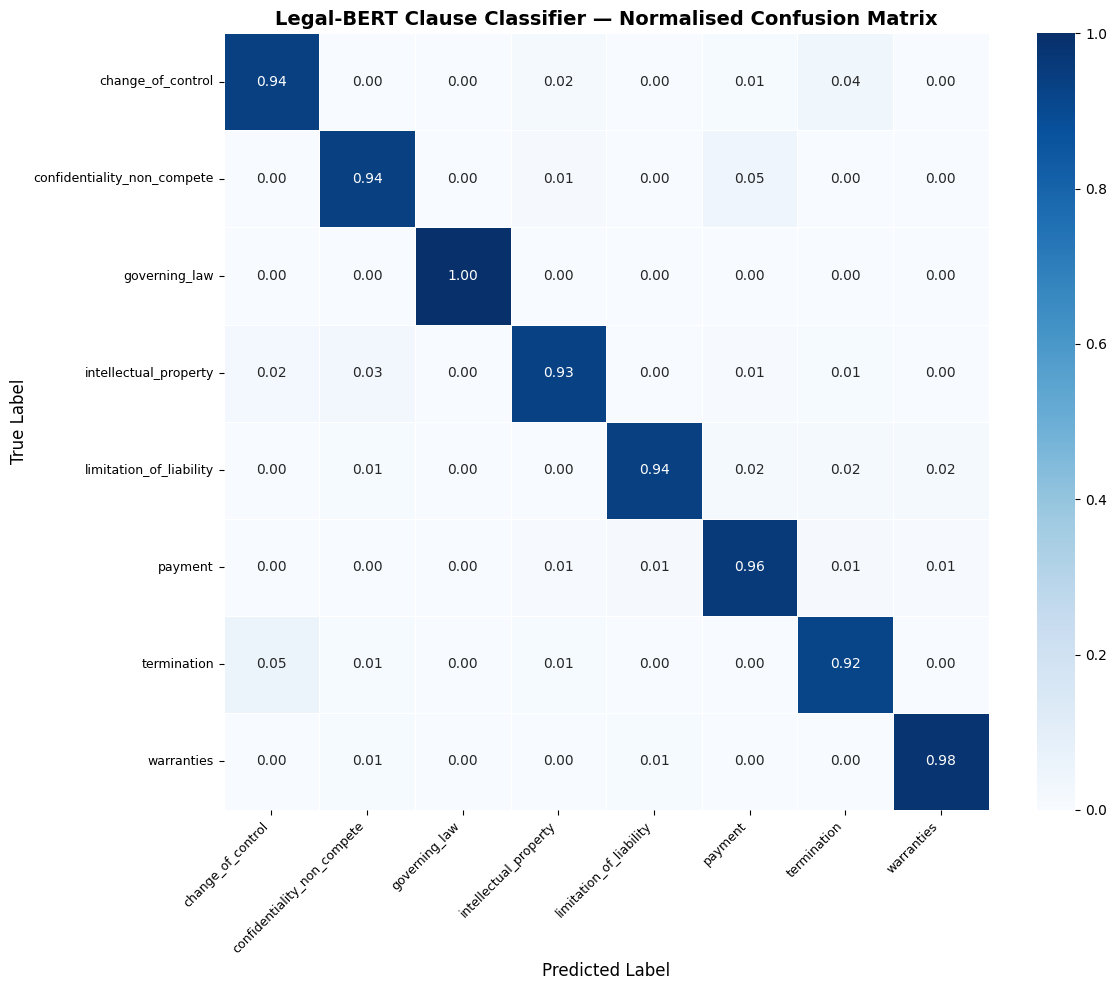

Confusion matrix saved.


In [34]:
# %% [markdown]
# ## Cell 26 — Confusion Matrix Heatmap

# %%
import seaborn as sns

cm = confusion_matrix(all_labels, all_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)  # Row-normalised

fig, ax = plt.subplots(figsize=(12, 10))

sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=LABEL_NAMES,
    yticklabels=LABEL_NAMES,
    linewidths=0.5,
    ax=ax,
)

ax.set_title("Legal-BERT Clause Classifier — Normalised Confusion Matrix", fontsize=14, fontweight="bold")
ax.set_xlabel("Predicted Label", fontsize=12)
ax.set_ylabel("True Label", fontsize=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)

plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()
print("Confusion matrix saved.")

In [35]:
# %% [markdown]
# ## Cell 27 — Save Model and Artifacts

# %%
import os

SAVE_DIR = "legal_bert_classifier"
os.makedirs(SAVE_DIR, exist_ok=True)

# Save fine-tuned model and tokenizer
model.save_pretrained(SAVE_DIR)
tokenizer.save_pretrained(SAVE_DIR)

# Save label encoder classes for inference
np.save(os.path.join(SAVE_DIR, "label_classes.npy"), label_encoder.classes_)

# Save clean classified dataset
df_clean.to_csv(os.path.join(SAVE_DIR, "cuad_classified_clean.csv"), index=False)

print(f"Model, tokenizer, and label encoder saved to: {SAVE_DIR}/")
print(f"Clean dataset saved to: {SAVE_DIR}/cuad_classified_clean.csv")
print(f"\nSaved files:")
for f in os.listdir(SAVE_DIR):
    print(f"  {f}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model, tokenizer, and label encoder saved to: legal_bert_classifier/
Clean dataset saved to: legal_bert_classifier/cuad_classified_clean.csv

Saved files:
  model.safetensors
  cuad_classified_clean.csv
  tokenizer_config.json
  config.json
  tokenizer.json
  label_classes.npy


In [36]:
# %% [markdown]
# ## Cell 28 — Inference Helper
#
# A clean reusable function for predicting the clause type of any new text.
# This will integrate with future pipeline modules (ontology, risk scoring, etc.)

# %%
def predict_clause_type(
    text: str,
    model,
    tokenizer,
    label_encoder,
    device,
    max_length: int = 256,
) -> dict:
    """
    Predict the clause type of a single legal clause text.

    Returns a dict with:
        clause_type  : predicted label string
        confidence   : softmax probability of predicted class
        all_scores   : dict of {label: probability} for all classes
    """
    model.eval()

    encoding = tokenizer(
        text,
        truncation=True,
        padding="max_length",
        max_length=max_length,
        return_tensors="pt",
    )

    input_ids      = encoding["input_ids"].to(device)
    attention_mask = encoding["attention_mask"].to(device)

    with torch.no_grad():
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        probs   = torch.softmax(outputs.logits, dim=1).squeeze().cpu().numpy()

    predicted_idx  = int(np.argmax(probs))
    predicted_label = label_encoder.classes_[predicted_idx]
    confidence      = float(probs[predicted_idx])

    all_scores = {
        label_encoder.classes_[i]: round(float(p), 4)
        for i, p in enumerate(probs)
    }

    return {
        "clause_type": predicted_label,
        "confidence":  round(confidence, 4),
        "all_scores":  all_scores,
    }


# Quick smoke test on two example clauses
test_clauses = [
    "Either party may terminate this agreement upon 30 days written notice.",
    "This agreement shall be governed by the laws of the State of New York.",
]

print("Inference smoke test:")
print("=" * 60)
for clause in test_clauses:
    result = predict_clause_type(clause, model, tokenizer, label_encoder, device)
    print(f"\nClause:      {clause}")
    print(f"Predicted:   {result['clause_type']}")
    print(f"Confidence:  {result['confidence']:.2%}")

Inference smoke test:

Clause:      Either party may terminate this agreement upon 30 days written notice.
Predicted:   termination
Confidence:  99.39%

Clause:      This agreement shall be governed by the laws of the State of New York.
Predicted:   governing_law
Confidence:  99.71%
